In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchtext.data import Field, BucketIterator, Example, Dataset
from datasets import load_dataset
import spacy
import random
import numpy as np
import time
import math

# 1. Set Seeds
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 2. Load Data & Define Tokenizers
# Only load once to save RAM
full_dataset = load_dataset('CohleM/english-to-nepali')

try:
    spacy_en = spacy.load('en_core_web_sm')
    def tokenize_en(text):
        return [tok.text for tok in spacy_en.tokenizer(text)]
except OSError:
    print("Spacy model not found, using split()")
    def tokenize_en(text):
        return text.split()

def tokenize_ne(text):
    return text.split()

# 3. Define TorchText Fields
SRC = Field(tokenize=tokenize_en, init_token='<sos>', eos_token='<eos>', lower=True)
TRG = Field(tokenize=tokenize_ne, init_token='<sos>', eos_token='<eos>')

# 4. Conversion Function
def prepare_data(hf_data):
    examples = []
    for item in hf_data:
        examples.append(Example.fromlist([item['en'], item['ne']], fields=[('src', SRC), ('trg', TRG)]))
    return Dataset(examples, fields=[('src', SRC), ('trg', TRG)])

# --- STEP 1: SLASH THE DATASET (30% usage) ---
print("Reducing dataset size...")
# Take 30% for the project
small_dataset = full_dataset['train'].train_test_split(test_size=0.7, seed=SEED)['train']

# --- STEP 2: Create Train, Val, AND Test ---
# Split the 30% chunk into: 80% Train, 20% Remaining
train_val_split = small_dataset.train_test_split(test_size=0.2, seed=SEED)
train_data = train_val_split['train']
remaining = train_val_split['test']

# Split the Remaining 20% into: 50% Val, 50% Test
val_test_split = remaining.train_test_split(test_size=0.5, seed=SEED)
val_data = val_test_split['train']
test_data = val_test_split['test'] # <--- This was missing before!

print(f"Train Size: {len(train_data)}")
print(f"Val Size:   {len(val_data)}")
print(f"Test Size:  {len(test_data)}")

# Convert to TorchText
train_ds = prepare_data(train_data)
val_ds = prepare_data(val_data)
test_ds = prepare_data(test_data)

# 5. Build Vocab
SRC.build_vocab(train_ds, min_freq=2)
TRG.build_vocab(train_ds, min_freq=2)

print(f"English Vocab: {len(SRC.vocab)}")
print(f"Nepali Vocab: {len(TRG.vocab)}")

# 6. Iterators
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 4

train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
    (train_ds, val_ds, test_ds),
    batch_size=BATCH_SIZE,
    device=device,
    sort_within_batch=True,
    sort_key=lambda x: len(x.src)
)

print("Data Loaded Successfully!")

Reducing dataset size...
Train Size: 42560
Val Size:   5320
Test Size:  5320
English Vocab: 15943
Nepali Vocab: 31091
Data Loaded Successfully!


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, enc_hid_dim, bidirectional=True)
        self.fc = nn.Linear(enc_hid_dim * 2, dec_hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [src len, batch size]
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        # outputs = [src len, batch size, hid dim * 2]
        # hidden = [2, batch size, hid dim]
        
        # Concatenate bidirectional hidden states and project to decoder dim
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))
        return outputs, hidden

In [3]:
class GeneralAttention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        # If dimensions differ, we need a linear layer to match them for dot product
        self.transform = nn.Linear(enc_hid_dim * 2, dec_hid_dim)

    def forward(self, hidden, encoder_outputs):
        # hidden = [batch size, dec hid dim]
        # encoder_outputs = [src len, batch size, enc hid dim * 2]
        
        batch_size = encoder_outputs.shape[1]
        src_len = encoder_outputs.shape[0]

        # Project encoder outputs to match decoder hidden dimension
        # [src len, batch, enc*2] -> [src len, batch, dec] -> [batch, src len, dec]
        projected_encoder_outputs = self.transform(encoder_outputs).permute(1, 0, 2)
        
        # Reshape hidden: [batch, dec, 1]
        hidden = hidden.unsqueeze(2)
        
        # Calculate scores: [batch, src len, dec] @ [batch, dec, 1] = [batch, src len, 1]
        attention = torch.bmm(projected_encoder_outputs, hidden).squeeze(2)

        return F.softmax(attention, dim=1)

In [4]:
class AdditiveAttention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        self.attn = nn.Linear((enc_hid_dim * 2) + dec_hid_dim, dec_hid_dim)
        self.v = nn.Linear(dec_hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden = [batch size, dec hid dim]
        # encoder_outputs = [src len, batch size, enc hid dim * 2]
        
        src_len = encoder_outputs.shape[0]
        
        # Repeat decoder hidden state src_len times
        # [batch, dec] -> [batch, src len, dec]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        
        # Permute encoder outputs: [batch, src len, enc * 2]
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        
        # Calculate Energy: tanh(W(h + s))
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        
        # Calculate Score: v * energy -> [batch, src len]
        attention = self.v(energy).squeeze(2)
        
        return F.softmax(attention, dim=1)

In [5]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU((enc_hid_dim * 2) + emb_dim, dec_hid_dim)
        self.fc_out = nn.Linear((enc_hid_dim * 2) + dec_hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input = [batch size] (one token at a time)
        input = input.unsqueeze(0) # [1, batch size]
        
        embedded = self.dropout(self.embedding(input)) # [1, batch, emb]
        
        # Calculate Attention Weights
        a = self.attention(hidden, encoder_outputs) # [batch, src len]
        a = a.unsqueeze(1) # [batch, 1, src len]
        
        # Apply Attention to Encoder Outputs (Weighted Sum)
        # [batch, 1, src len] @ [batch, src len, enc*2] = [batch, 1, enc*2]
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        weighted = torch.bmm(a, encoder_outputs)
        weighted = weighted.permute(1, 0, 2) # [1, batch, enc*2]
        
        # RNN Input: Embeddings + Weighted Context
        rnn_input = torch.cat((embedded, weighted), dim=2)
        
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        
        # Prediction
        assert (output == hidden).all()
        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)
        
        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))
        
        return prediction, hidden.squeeze(0), a.squeeze(1)

In [6]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        
        # Tensor to store decoder outputs
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)
        
        # Save attention weights for visualization later
        attentions = torch.zeros(trg_len, batch_size, src.shape[0]).to(self.device)
        
        # Encode
        encoder_outputs, hidden = self.encoder(src)
        
        # First input is <sos>
        input = trg[0,:]
        
        for t in range(1, trg_len):
            output, hidden, a = self.decoder(input, hidden, encoder_outputs)
            outputs[t] = output
            attentions[t] = a
            
            top1 = output.argmax(1)
            input = trg[t] if random.random() < teacher_forcing_ratio else top1
            
        return outputs, attentions

In [7]:
INPUT_DIM = len(SRC.vocab)
OUTPUT_DIM = len(TRG.vocab)
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
ENC_HID_DIM = 512
DEC_HID_DIM = 512
DROPOUT = 0.5

# --- Model 1: Additive Attention ---
attn_additive = AdditiveAttention(ENC_HID_DIM, DEC_HID_DIM)
enc_add = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DROPOUT)
dec_add = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DROPOUT, attn_additive)
model_additive = Seq2Seq(enc_add, dec_add, device).to(device)

# --- Model 2: General Attention ---
attn_general = GeneralAttention(ENC_HID_DIM, DEC_HID_DIM)
enc_gen = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DROPOUT)
dec_gen = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DROPOUT, attn_general)
model_general = Seq2Seq(enc_gen, dec_gen, device).to(device)

# Initialize weights
def init_weights(m):
    for name, param in m.named_parameters():
        if 'weight' in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)

model_additive.apply(init_weights)
model_general.apply(init_weights)

print("Models Initialized")

Models Initialized


In [8]:
optimizer_add = optim.Adam(model_additive.parameters())
optimizer_gen = optim.Adam(model_general.parameters())
TRG_PAD_IDX = TRG.vocab.stoi[TRG.pad_token]
criterion = nn.CrossEntropyLoss(ignore_index=TRG_PAD_IDX)

def train(model, iterator, optimizer, clip):
    model.train()
    epoch_loss = 0
    for i, batch in enumerate(iterator):
        src, trg = batch.src, batch.trg
        optimizer.zero_grad()
        output, _ = model(src, trg)
        
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        trg = trg[1:].view(-1)
        
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(iterator)

def evaluate(model, iterator):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for i, batch in enumerate(iterator):
            src, trg = batch.src, batch.trg
            output, _ = model(src, trg, 0) # Turn off teacher forcing
            
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            trg = trg[1:].view(-1)
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(iterator)

# --- Train Loop (Run for at least 5-10 epochs) ---
N_EPOCHS = 5 # Increase this for better results
CLIP = 1

history = {'gen_train': [], 'gen_val': [], 'add_train': [], 'add_val': []}

print("Starting Training...")
for epoch in range(N_EPOCHS):
    start_time = time.time()
    
    # Train Additive
    train_loss_add = train(model_additive, train_iterator, optimizer_add, CLIP)
    valid_loss_add = evaluate(model_additive, valid_iterator)
    
    # Train General
    train_loss_gen = train(model_general, train_iterator, optimizer_gen, CLIP)
    valid_loss_gen = evaluate(model_general, valid_iterator)
    
    history['add_train'].append(train_loss_add)
    history['add_val'].append(valid_loss_add)
    history['gen_train'].append(train_loss_gen)
    history['gen_val'].append(valid_loss_gen)
    
    print(f'Epoch: {epoch+1:02}')
    print(f'\tAdditive - Train Loss: {train_loss_add:.3f} | Val. Loss: {valid_loss_add:.3f} | Val. PPL: {math.exp(valid_loss_add):.3f}')
    print(f'\tGeneral  - Train Loss: {train_loss_gen:.3f} | Val. Loss: {valid_loss_gen:.3f} | Val. PPL: {math.exp(valid_loss_gen):.3f}')

Starting Training...
Epoch: 01
	Additive - Train Loss: 6.298 | Val. Loss: 5.478 | Val. PPL: 239.288
	General  - Train Loss: 6.367 | Val. Loss: 5.587 | Val. PPL: 266.813
Epoch: 02
	Additive - Train Loss: 5.017 | Val. Loss: 5.209 | Val. PPL: 182.985
	General  - Train Loss: 5.155 | Val. Loss: 5.271 | Val. PPL: 194.615
Epoch: 03
	Additive - Train Loss: 4.398 | Val. Loss: 5.223 | Val. PPL: 185.436
	General  - Train Loss: 4.552 | Val. Loss: 5.189 | Val. PPL: 179.348
Epoch: 04
	Additive - Train Loss: 4.037 | Val. Loss: 5.306 | Val. PPL: 201.528
	General  - Train Loss: 4.158 | Val. Loss: 5.257 | Val. PPL: 191.926
Epoch: 05
	Additive - Train Loss: 3.844 | Val. Loss: 5.436 | Val. PPL: 229.505
	General  - Train Loss: 3.897 | Val. Loss: 5.400 | Val. PPL: 221.333


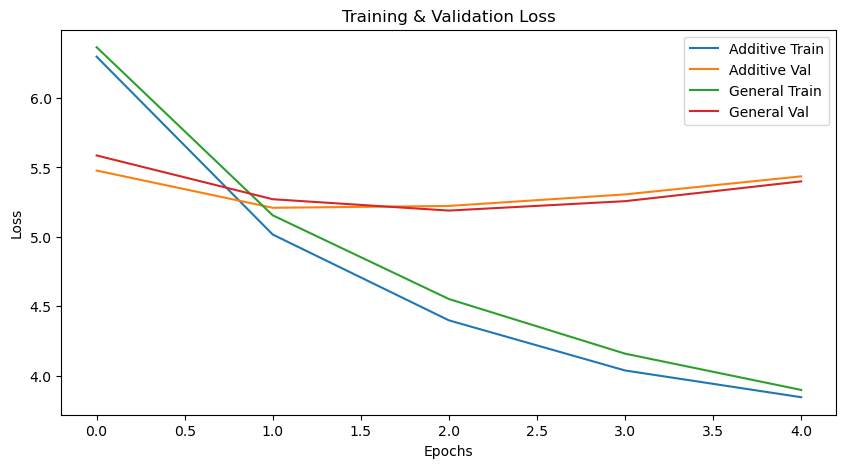

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history['add_train'], label='Additive Train')
plt.plot(history['add_val'], label='Additive Val')
plt.plot(history['gen_train'], label='General Train')
plt.plot(history['gen_val'], label='General Val')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Source: but a prophet of yahweh was there , whose name was oded : and he went out to meet the army that came to samaria , and said to them , " behold , because yahweh , the god of your fathers , was angry with judah , he has delivered them into your hand , and you have slain them in a rage which has reached up to heaven .
Target: तर त्यहाँ परमप्रभुको एउटा अगमवक्ता थिए। यो अगमवक्ताको नाउँ ओबेद थियो। ओबेदले ती इस्राएली मानिसहरूसित भेट गरे जो सामरिया फर्की आएका थिए। ओदेदले इस्राएली सेनालाई भने, “तिमीहरूका पुर्खाहरूले आज्ञा पालन गर्ने परमप्रभु परमेश्वरले तिमीहरूलाई यहूदाका मानिसहरूलाई परास्त पार्न दिनु भएको थियो किनभने उहाँ तिनीहरूसित क्रोधित हुनुहुन्थ्यो। तिमीहरूले यहूदाका मानिसहरूलाई अति नीच प्रकारले मार्यौ अनि दण्ड दियौ अब परमेश्वर तिमीहरूसित क्रोधित हुनुहुन्छ।
Predicted (Additive): “तर तिनले अगमवक्ताको अगमवक्ता थिए। अगमवक्ताको अगमवक्ताको अगमवक्ताको अगमवक्ता थिए। यहूदाका मानिसहरूलाई परास्त गरे। तिनले यहूदाका मानिसहरूलाई परास्त “तिमीहरूका पुर्खाहरूले <unk> <unk> <unk> <unk> सेनालाई परास्

C:\Users\gaurav\AppData\Local\Temp\ipykernel_14916\346442328.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['']+['<sos>']+[t.lower() for t in sentence]+['<eos>'], rotation=45)
C:\Users\gaurav\AppData\Local\Temp\ipykernel_14916\346442328.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['']+translation)
c:\Users\gaurav\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gaurav\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\gaurav\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWar

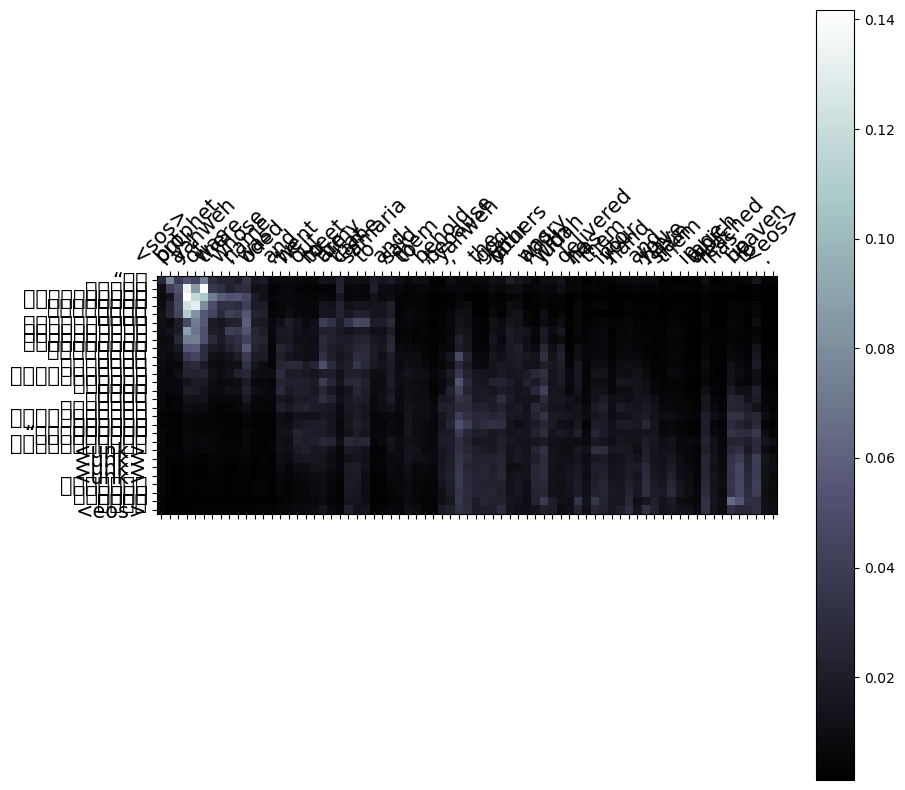

In [10]:
import matplotlib.ticker as ticker

def display_attention(sentence, translation, attention):
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111)
    
    attention = attention.squeeze(1).cpu().detach().numpy()
    cax = ax.matshow(attention, cmap='bone')
    fig.colorbar(cax)
    
    ax.tick_params(labelsize=15)
    
    # Ensure axes ticks align with sentence length
    ax.set_xticklabels(['']+['<sos>']+[t.lower() for t in sentence]+['<eos>'], rotation=45)
    ax.set_yticklabels(['']+translation)
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()
    plt.close()

def translate_sentence(sentence, src_field, trg_field, model, device, max_len=50):
    model.eval()
    
    if isinstance(sentence, str):
        tokens = [token.text.lower() for token in spacy_en(sentence)]
    else:
        tokens = [token.lower() for token in sentence]

    tokens = [src_field.init_token] + tokens + [src_field.eos_token]
    src_indexes = [src_field.vocab.stoi[token] for token in tokens]
    src_tensor = torch.LongTensor(src_indexes).unsqueeze(1).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    trg_indexes = [trg_field.vocab.stoi[trg_field.init_token]]
    attentions = torch.zeros(max_len, 1, len(src_indexes)).to(device)

    for i in range(max_len):
        trg_tensor = torch.LongTensor([trg_indexes[-1]]).to(device)
        
        with torch.no_grad():
            output, hidden, attention = model.decoder(trg_tensor, hidden, encoder_outputs)

        attentions[i] = attention
        pred_token = output.argmax(1).item()
        trg_indexes.append(pred_token)

        if pred_token == trg_field.vocab.stoi[trg_field.eos_token]:
            break
    
    trg_tokens = [trg_field.vocab.itos[i] for i in trg_indexes]
    return trg_tokens[1:], attentions[:len(trg_tokens)-1]

# --- Run Visualization ---
example_idx = 10
src_sentence = vars(train_ds.examples[example_idx])['src']
target_sentence = vars(train_ds.examples[example_idx])['trg']

print(f"Source: {' '.join(src_sentence)}")
print(f"Target: {' '.join(target_sentence)}")

translation, attention = translate_sentence(src_sentence, SRC, TRG, model_additive, device)
print(f"Predicted (Additive): {' '.join(translation)}")

display_attention(src_sentence, translation, attention)

In [12]:
# 1. Determine which model had the lowest validation loss overall
min_loss_additive = min(history['add_val'])
min_loss_general = min(history['gen_val'])

print(f"Lowest Validation Loss (Additive): {min_loss_additive:.4f}")
print(f"Lowest Validation Loss (General):  {min_loss_general:.4f}")

# 2. Compare and Save the Winner
if min_loss_additive < min_loss_general:
    print(" Additive Attention performed better! Saving Additive model...")
    torch.save(model_additive.state_dict(), 'best_model.pt')
else:
    print(" General Attention performed better! Saving General model...")
    torch.save(model_general.state_dict(), 'best_model.pt')

print("Done. The best model is saved as 'best_model.pt'")


Lowest Validation Loss (Additive): 5.2094
Lowest Validation Loss (General):  5.1893
 General Attention performed better! Saving General model...
Done. The best model is saved as 'best_model.pt'
